# Qiskit Bootcamp Challenge 2025!!

Welcome to the Qiskit v2.x! This notebook is designed to challenge you on the previously provided content and also covers some new content to keep it interesting.

For more detailed information, please refer to the official Qiskit documentation.

**Instructions:**
1. Read the explanation for each concept.
2. Complete the coding exercise in the designated cell.

## Final Challenge: Build Your Own Quantum Circuit

Congratulations on reaching the final challenge! You've now seen all the fundamental building blocks of Qiskit: from creating circuits and adding gates to using the Primitives, handling parameters, and transpiling for a backend.

Your final task is to put all these pieces together. Your challenge is to **design and execute a quantum circuit of your own interest.**

> **There is no single correct answer.** This is your opportunity to be creative and show what you've learned. This challenge is about **50% functionality** and **50% creativity**. 

If you're not sure what to build, here are a few ideas:

* Try to build the circuit for Quantum Teleportation (it only uses H, CNOT, X, Z, and measurement!).
* Create a simple variational circuit ("ansatz") using `ParameterVector` and find its expectation value with the `Estimator`.
* Design a circuit, export it to an OpenQASM 3.0 string, and then load it back in.

### What to Include

Try to incorporate as many of the concepts as possible:
1.  **Circuit Creation:** Build a `QuantumCircuit`.
2.  **Gates:** Use a mix of single-qubit (H, X, RY) and multi-qubit (CNOT) gates.
3.  **Transpilation:** Use `generate_preset_pass_manager` to transpile your circuit for a backend (like `AerSimulator` or `FakeVigoV2`).
4.  **Primitives:** Use the `Sampler` to get counts or the `Estimator` to measure an observable (`SparsePauliOp`).
5.  **Visualization:** Plot your results! (e.g., `plot_histogram` or print the final expectation value).

------------------------------------------------

The objective of this project is to evaluate a Quantum Machine Learning approach for breast cancer detection.  
Specifically, I implemented a Quantum Support Vector Classifier (QSVC) and compare its performance against a classical Random Forest Classifier.  
This comparison aims to assess the potential for a quantum advantage in solving this classification problem.

In addition, I performed a shot noise and shot statistics analysis using AerSimulator. By varying the number of measurement shots, I can observe how statistical fluctuations inherent to quantum sampling affect both the estimated kernel fidelities and the resulting classification accuracy. Furthermore, I extended this analysis by including noisy simulations based on FakeVIgoV2, in order to assess the combined impact of hardware noise and finite sampling on the QSVC performance.

In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [23]:
# Your code goes here!
bc_data = load_breast_cancer()
print(bc_data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

After loading the WBCD dataset, the data is scaled. Following this, we will observe the probability distributions

In [24]:
print(bc_data.feature_names)
features = bc_data.data

labels = bc_data.target
features = MinMaxScaler(feature_range=(0, 2*np.pi)).fit_transform(features)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


The original WBCD dataset contains 30 distinct features. In Quantum Machine Learning, a standard approach is to map each classical feature to a single qubit. A model using the full dataset would therefore require a 30-qubit circuit.

However, current quantum hardware suffers from significant limitations, most notably noise and gate errors.

Running a 30-qubit circuit for this type of problem is currently impractical. The depth and complexity of such a circuit would lead to an accumulation of noise that would overwhelm the computational signal, rendering the output unreliable.

For this reason, a pragmatic compromise is necessary: we reduce the feature set to 4. This allows us to build a 4-qubit model, which is far more manageable and less susceptible to noise.

The following 4 features were selected based on their high intuitive and clinical relevance for breast cancer diagnosis:

-   mean radius: Provides a core measure of the tumor's size.
-   mean texture: Describes the uniformity of the tissue (high variation is often a sign of malignancy).
-   mean compactness: Relates to the tumor's density and shape.
-   mean concavity: Measures the severity of indentations in the tumor's contour, which is a strong indicator of invasive growth.

By selecting these 4 features, we maintain a "rich" dataset that describes the tumor's key morphological characteristics while making the problem computationally feasible for a QML architecture.

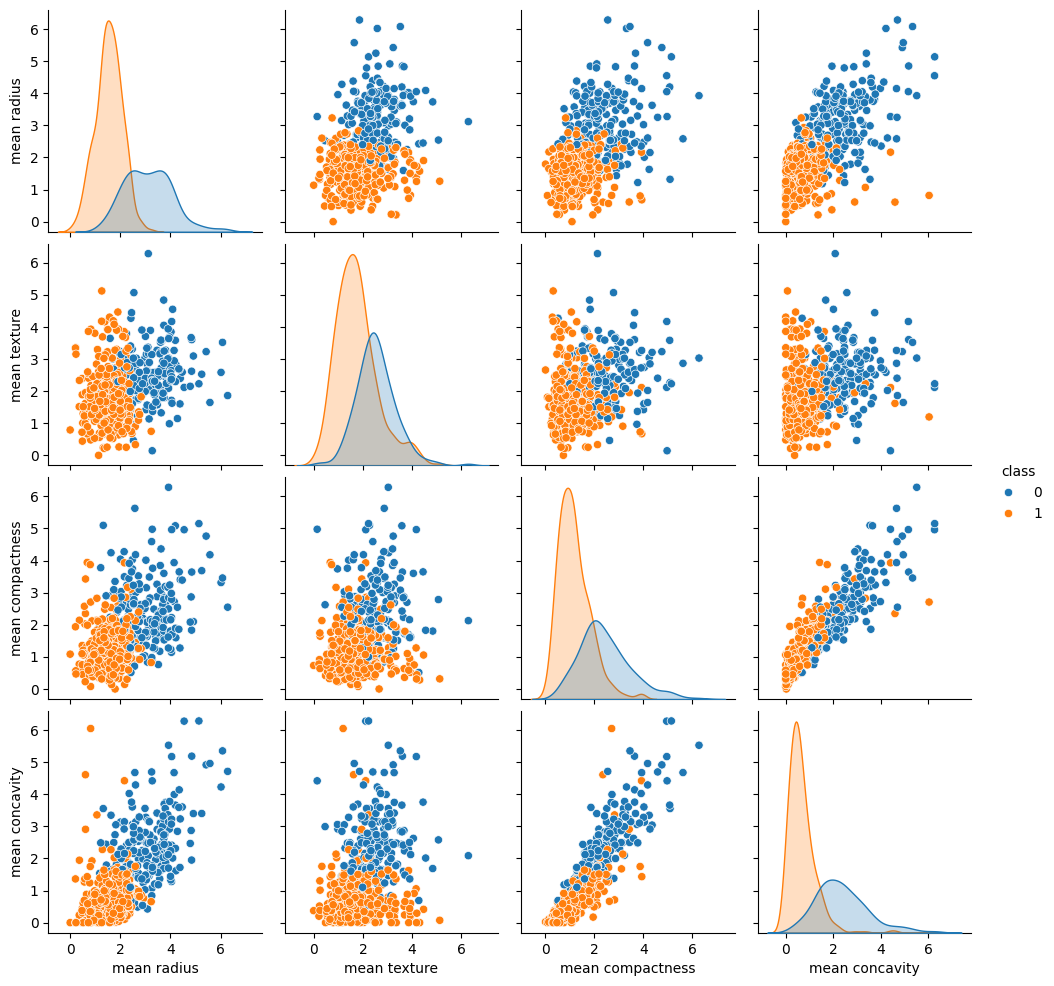

In [25]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean compactness",
    "mean concavity"
]

df = pd.DataFrame(features, columns=bc_data.feature_names)[selected_features] 
df["class"] = bc_data.target

features = df[selected_features].values
labels = bc_data.target


sns.pairplot(df, hue="class")


In [26]:
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, random_state=42
)

A Random Forest classifier was chosen for this task due to its robust ability to model complex, non-linear patterns within the feature set

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(train_features, train_labels)
y_pred = rf.predict(test_features)

print("Accuracy:", accuracy_score(test_labels, y_pred))

Accuracy: 0.9473684210526315


Text(0.5, 1.0, 'Confusion Matrix for RandomForest')

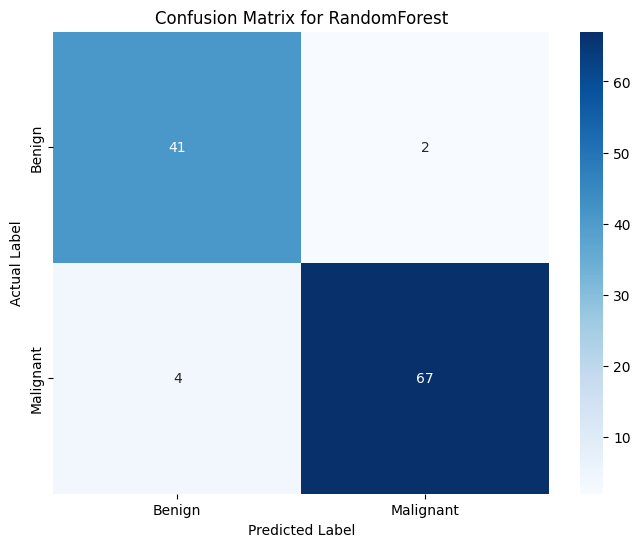

In [28]:
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])


plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for RandomForest')

Now I can define the Quantum Circuit. The feature map is the most critical component of a quantum kernel algorithm, as its purpose is to encode classical data into the complex, high-dimensional state space of the quantum computer. The goal is to find a transformation that makes the data points more easily separable. The choice of this map is a crucial design decision; after experimenting with several architectures, the custom feature map defined below was found to yield the best classification results for this specific problem.

In [29]:
def CustomFeatureMap(num_qubits, reps):

    x = ParameterVector("x", num_qubits)
    qc = QuantumCircuit(num_qubits)

    qc.h(range(num_qubits))

    for _ in range(reps):
        
        for i in range(num_qubits):
            qc.ry(x[i], i)
            
        
        for i in range(num_qubits):
            non_linear_term = x[i] * x[(i + 1) % num_qubits]
            qc.rz(non_linear_term, i)

        
        for i in range(num_qubits):
            qc.cx(i, (i + 1) % num_qubits)

        qc.barrier()



    return qc

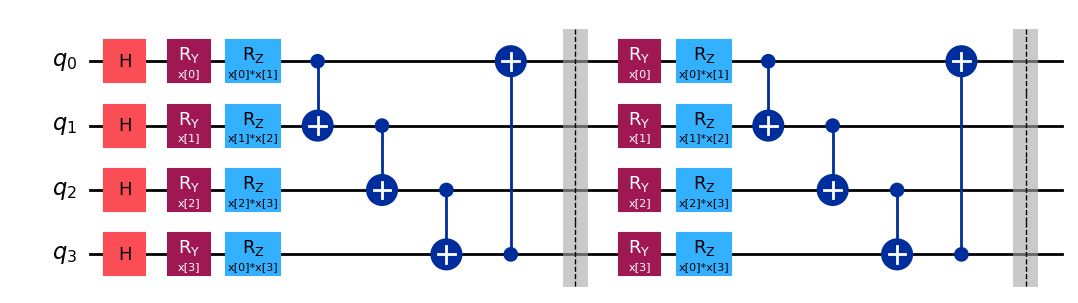

In [30]:
num_qubits = num_qubits = features.shape[1] 
custom_fm = CustomFeatureMap(num_qubits,reps = 2)
custom_fm.draw("mpl")

This cell executes the core QSVC logic. First, it configures the backend by setting up an AerSimulator and a PassManager. Next, it defines the FidelityQuantumKernel using the custom feature map and the Sampler; this kernel's job is to calculate the "similarity" between the quantum states of our data points. The kernel then computes the similarity matrices for the training and testing data, which is the most computationally intensive step. Finally, a classical SVC is trained using the kernel="precomputed" setting, which tells it to use our quantum-computed matrices to find the decision boundary.

A quantum feature map $\phi(x)$ naturally gives rise to a quantum kernel $k = \phi(x_i)^\dagger \phi(x_j)$ , which can be seen as a measure of fidelity: if $k$ is large, $x_i,x_j$ are close to each other. With finite data, a kernel matrix arises $K_{ij} = |\bra{\phi}^\dagger(x_i) \ket{\phi}(x_i)|^2$. Calculating each element of this matrix by calculating the transition amplitude $|\bra{\phi}^\dagger(x_i) \ket{\phi}(x_i)|^2 = |\bra{0}^{\otimes n } U^\dagger_\phi(x_i) U_\phi^\dagger(x_j)\ket{0}^{\otimes n}|^2$.
This provides an estimate of the quantum kernel matrix, which can be used in a kernel machine learning algorithm (SVC)

In [31]:
aer_backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=3, backend=aer_backend)
sampler = Sampler(aer_backend)


fidelity = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=custom_fm)

print("Computing training kernel matrix ...")



kernel_matrix_train = quantum_kernel.evaluate(x_vec=train_features)



print("Computing test kernel matrix...")
kernel_matrix_test = quantum_kernel.evaluate(x_vec=test_features, y_vec=train_features)


qsvc = SVC(kernel="precomputed")
qsvc.fit(kernel_matrix_train, train_labels)

Computing training kernel matrix ...
Computing test kernel matrix...


,C,1.0
,kernel,'precomputed'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
qsvc_pred = qsvc.predict(kernel_matrix_test)


qsvc_accuracy = accuracy_score(test_labels, qsvc_pred)
print(f"Accuracy QSVC: {qsvc_accuracy}")

Accuracy QSVC: 0.9122807017543859


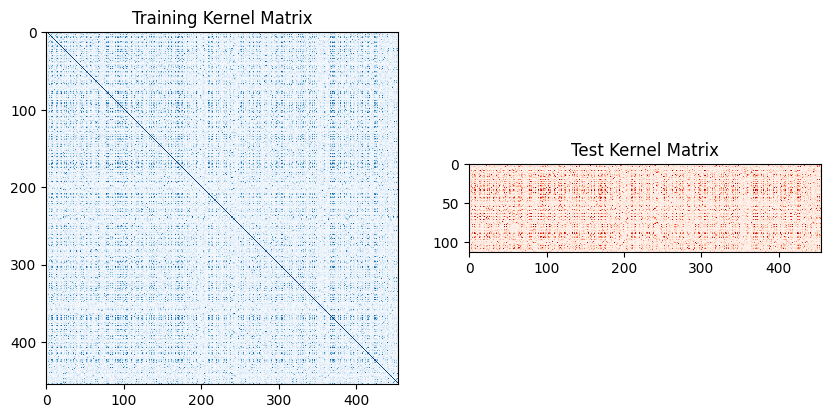

In [33]:
fig, axs = plt.subplots(1,2, figsize = (10,5))
axs[0].imshow(np.asmatrix(kernel_matrix_train), interpolation = 'nearest', origin ='upper',cmap='Blues')
axs[0].set_title("Training Kernel Matrix")

axs[1].imshow(np.asmatrix(kernel_matrix_test), interpolation = 'nearest', origin ='upper',cmap='Reds')
axs[1].set_title("Test Kernel Matrix")
plt.show()

This visualization confirms the quantum kernel was computed successfully. The Training Kernel Matrix (left) is correctly square and symmetric, with a strong diagonal line confirming that the self-similarity (fidelity) of each data point is 1. Its complex, dot-like off-diagonal pattern shows our feature map is creating a rich similarity landscape. The Test Kernel Matrix (right) is correctly rectangular (N_test x N_train) and shows the similarity of each test point against all training points, which is the data the SVC.predict() method will use. These heatmaps show the most computationally intensive part of the QSVC has worked, and the complex patterns visible are the new similarity measure the classical SVM will use to find the optimal decision boundary.

Text(0.5, 1.0, 'Confusion Matrix for QSVC')

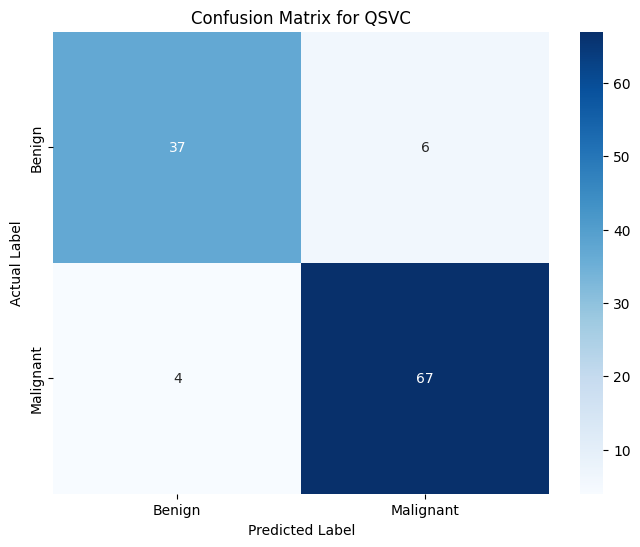

In [34]:
cm = confusion_matrix(test_labels, qsvc_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])


plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for QSVC')

Now I want to perform a shot noise analysis using `AerSimulator`. 
By varying the number of shots, we can study how statistical fluctuations affect the estimated fidelities and the resulting classification accuracy.

In [35]:
from qiskit_ibm_runtime import SamplerOptions

ideal_backend = AerSimulator()
pm = generate_preset_pass_manager(backend=ideal_backend, optimization_level=3)
transpiled_feature_map = pm.run(custom_fm)


# 3. Lista di Shots
shots_list = [10, 50, 100, 200, 500, 1000, 2000]
accuracies_ideal = []


for shots in shots_list:
    print(f"Testing {shots} shots...")

    options = SamplerOptions(default_shots=shots)
    sampler = Sampler(ideal_backend, options=options)

    fidelity = ComputeUncompute(sampler=sampler)
    
    
    quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=transpiled_feature_map)
    
    
    kernel_matrix_train = quantum_kernel.evaluate(x_vec=train_features)
    kernel_matrix_test = quantum_kernel.evaluate(x_vec=test_features, y_vec=train_features)
    
    
    qsvc = SVC(kernel="precomputed", C=1.0) 
    qsvc.fit(kernel_matrix_train, train_labels)
    qsvc_pred = qsvc.predict(kernel_matrix_test)
    acc = accuracy_score(test_labels, qsvc_pred)
    
    accuracies_ideal.append(acc)
    print(f"Accuracy: {acc*100:.2f}%")

Testing 10 shots...
Accuracy: 75.44%
Testing 50 shots...
Accuracy: 86.84%
Testing 100 shots...
Accuracy: 89.47%
Testing 200 shots...
Accuracy: 90.35%
Testing 500 shots...
Accuracy: 89.47%
Testing 1000 shots...
Accuracy: 90.35%
Testing 2000 shots...
Accuracy: 91.23%


The orange curve corresponds to a nonlinear least-squares fit using the model:


$$\text{Accuracy}(N) = A - \frac{B}{\sqrt{N}}$$



As the number of shots increases, the effect of shot noise diminishes and the QSVC accuracy approaches its asymptotic value A.  
This confirms the expected trend — a higher sampling precision leads to more stable quantum kernel estimates and, consequently, better model accuracy.

Asymptotic accuracy A = 0.9306 ± 0.0077
Parameter B = 0.5263 ± 0.0544


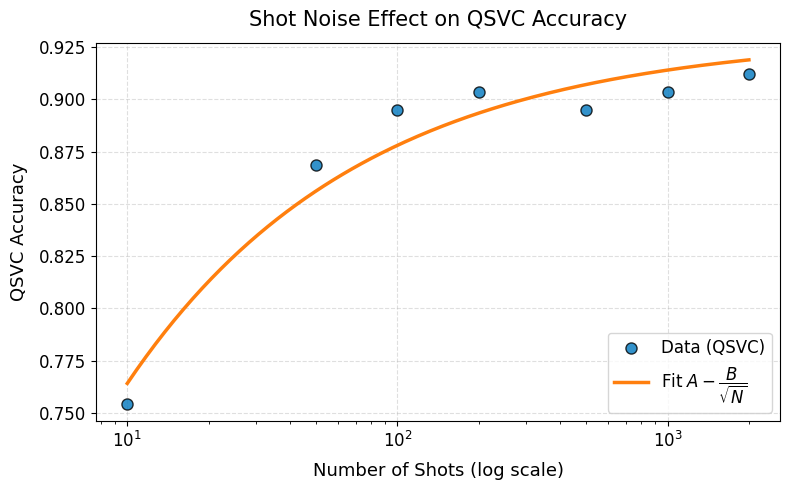

In [ ]:
from scipy.optimize import curve_fit

def acc_model(x,A,B):
    return A - B / np.sqrt(x)

shots_array = np.array(shots_list, dtype=float)
acc_array = np.array(accuracies_ideal, dtype=float)

popt, pcov = curve_fit(acc_model,shots_array,acc_array,p0=[acc_array.max(), 0.1])

A_fit, B_fit = popt
A_err, B_err = np.sqrt(np.diag(pcov))

print(f"Asymptotic accuracy A = {A_fit:.4f} ± {A_err:.4f}")
print(f"Parameter B = {B_fit:.4f} ± {B_err:.4f}")


N_plot = np.logspace(np.log10(shots_array.min()),np.log10(shots_array.max()),200)
acc_fit_plot = acc_model(N_plot, *popt)


plt.figure(figsize=(8, 5))


plt.plot(shots_array, acc_array, 'o', color='#0077be', markersize=8, label='Data (QSVC)', markeredgecolor='black', alpha=0.8)
plt.plot(N_plot, acc_fit_plot, '-', color='#ff7f0e', linewidth=2.5, label=r'Fit $A - \dfrac{B}{\sqrt{N}}$')
plt.xscale('log')


plt.xlabel('Number of Shots (log scale)', fontsize=13, labelpad=8)
plt.ylabel('QSVC Accuracy', fontsize=13, labelpad=8)
plt.title('Shot Noise Effect on QSVC Accuracy', fontsize=15, pad=12)


plt.grid(linestyle='--', alpha=0.4)
plt.legend(fontsize=12, loc='lower right', frameon=True, shadow=False)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

In the following simulation, I extended the previous shot noise analysis by adding realistic hardware noise to the quantum circuit execution.  
This is achieved by using a fake backend that emulates the behavior of a real IBM Quantum device, including gate errors, readout errors, and device coupling constraints.

In [71]:
from qiskit_ibm_runtime import SamplerOptions


noisy_backend = FakeVigoV2()

pm_noisy = generate_preset_pass_manager(backend=noisy_backend,optimization_level=3)
transpiled_feature_map_noisy = pm_noisy.run(custom_fm)

shots_list = [10, 50, 100, 200, 500, 1000, 2000]
accuracies_noisy = []

for shots in shots_list:
    print(f"\nTesting {shots} noisy shots...")

    
    options_noisy = SamplerOptions(default_shots=shots)
    sampler_noisy = Sampler(mode=noisy_backend, options=options_noisy)

    
    fidelity_noisy = ComputeUncompute(sampler=sampler_noisy,pass_manager=pm_noisy)

    qk_noisy = FidelityQuantumKernel(fidelity=fidelity_noisy,feature_map=transpiled_feature_map_noisy)

    K_train_noisy = qk_noisy.evaluate(x_vec=train_features)
    K_test_noisy  = qk_noisy.evaluate(x_vec=test_features, y_vec=train_features)


    clf_noisy = SVC(kernel="precomputed", C=1.0)
    clf_noisy.fit(K_train_noisy, train_labels)
    pred_noisy = clf_noisy.predict(K_test_noisy)

    acc_noisy = accuracy_score(test_labels, pred_noisy)
    accuracies_noisy.append(acc_noisy)
    print(f"Noisy accuracy: {acc_noisy * 100:.2f}%")



Testing 10 noisy shots...
Noisy accuracy: 73.68%

Testing 50 noisy shots...
Noisy accuracy: 85.96%

Testing 100 noisy shots...
Noisy accuracy: 85.09%

Testing 200 noisy shots...
Noisy accuracy: 88.60%

Testing 500 noisy shots...
Noisy accuracy: 89.47%

Testing 1000 noisy shots...
Noisy accuracy: 88.60%

Testing 2000 noisy shots...
Noisy accuracy: 88.60%


[NOISY] Asymptotic accuracy A = 0.9116 ± 0.0083
[NOISY] Parameter B = 0.5246 ± 0.0589


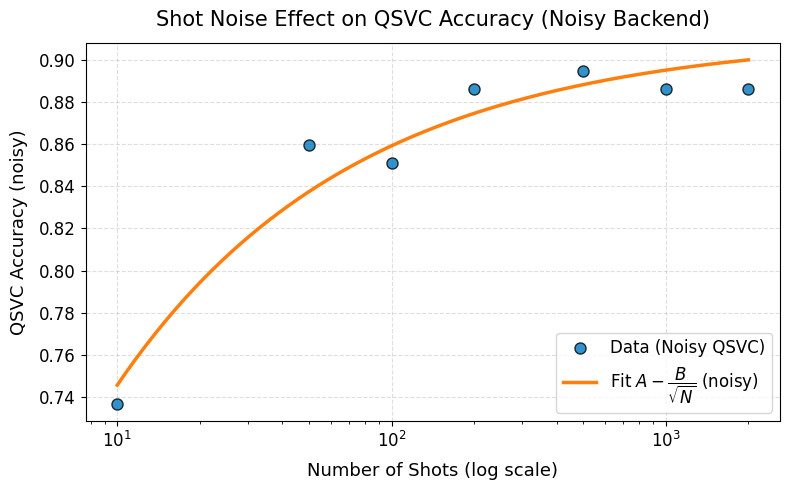

In [72]:

shots_array_noisy = np.array(shots_list, dtype=float)
acc_array_noisy   = np.array(accuracies_noisy, dtype=float)


popt_noisy, pcov_noisy = curve_fit(acc_model, shots_array_noisy, acc_array_noisy,p0=[acc_array_noisy.max(), 0.1])

A_fit_noisy, B_fit_noisy = popt_noisy
A_err_noisy, B_err_noisy = np.sqrt(np.diag(pcov_noisy))

print(f"[NOISY] Asymptotic accuracy A = {A_fit_noisy:.4f} ± {A_err_noisy:.4f}")
print(f"[NOISY] Parameter B = {B_fit_noisy:.4f} ± {B_err_noisy:.4f}")


N_plot_noisy = np.logspace( np.log10(shots_array_noisy.min()),np.log10(shots_array_noisy.max()),200)
acc_fit_plot_noisy = acc_model(N_plot_noisy, *popt_noisy)


plt.figure(figsize=(8, 5))

plt.plot(shots_array_noisy,acc_array_noisy,'o',color='#0077be',markersize=8,label='Data (Noisy QSVC)',markeredgecolor='black', alpha=0.8)
plt.plot(N_plot_noisy,acc_fit_plot_noisy,'-',color='#ff7f0e',linewidth=2.5,label=r'Fit $A - \dfrac{B}{\sqrt{N}}$ (noisy)')
plt.xscale('log')

plt.xlabel('Number of Shots (log scale)', fontsize=13, labelpad=8)
plt.ylabel('QSVC Accuracy (noisy)', fontsize=13, labelpad=8)
plt.title('Shot Noise Effect on QSVC Accuracy (Noisy Backend)', fontsize=15, pad=12)

plt.grid(linestyle='--', alpha=0.4)
plt.legend(fontsize=12, loc='lower right', frameon=True, shadow=False)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()



The final results provide a clear and insightful comparison:

-   Classical Random Forest: 0.95 Accuracy
-   Quantum (QSVC) (Asymptotic IDEAL): 0.93 Accuracy
-   Quantum (QSVC) (Asymptotic VIGO): 0.91 Accuracy

In this direct comparison, the classical Random Forest model outperformed our custom QSVC in terms of raw accuracy.

However, the QSVC's accuracy remains a significant and promising result. It demonstrates that the quantum kernel is effective and that the model can successfully learn complex data patterns in an ideal, noiseless environment.

As expected, the shot noise analysis reveals that the algorithm’s performance degrades as the number of measurement shots decreases.
Moreover, when including hardware noise through the realistic FakeVigoV2 backend, the overall accuracy further drops, reflecting the additional effects of gate and readout errors present in current superconducting devices.

Although no quantum advantage is observed at this stage, these results highlight a key insight: current limitations arise primarily from hardware imperfections rather than from the algorithmic framework itself. The observed degradation in the noisy simulation realistically mirrors what would occur on an actual quantum processor, illustrating today’s technological bottleneck.

Nevertheless, this experiment validates the potential of Quantum Machine Learning. As quantum hardware continues to improve and noise-mitigation techniques advance, algorithms such as the QSVC are expected to evolve into powerful and reliable tools for solving complex, real-world problems.

## Well Done!

Thank you for completing the PushQuantum Qiskit Bootcamp and Challenge. We hope this has been a helpful and fun introduction, and we're excited to see you at one of our future events.